In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

import pandas as pd
import numpy as np
import scipy
import nibabel as nb
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
    
sys.path.insert(1, "../../")

# import precision_mapping as pm
import voxel_analysis as pm
import CAP_tools


sys.path.insert(1, "../../network_control")
import surface_mapping as sfm

# Parameters

In [2]:
priors_path = "../resources/priors.mat"

priors = scipy.io.loadmat(priors_path)
FC, spatial, network_labels, _ = priors["Priors"][0, 0]
network_labels = np.array([lab[0][0] for lab in network_labels])
FC, spatial = FC.T, spatial.T

template_cifti = nb.load(pm.constants.EXAMPLE_DTSERIES)

In [3]:
rs_dtseries_list_path = "/data/data7/network_control/scripts/_params/EC_CAP_analysis/EC_CAP_analysis_RS_fMRI_maps_dtseries_list.txt"

with open(rs_dtseries_list_path, "r") as f:
    dtseries_paths = f.read().strip().split()

subject_list = [path.split("/MNI")[0].split("/")[-1] for path in dtseries_paths]

cached_dtseries_paths = pm.utils.cache_tmp_path(dtseries_paths, write_cache=False)

Caching paths in /tmp:   0%|          | 0/54 [00:00<?, ?it/s]

In [4]:
pm_dir = "/data/data7/network_control/results/EC_analysis/precision_maps/RS_fMRI_maps"
# pm_dir = "/data/data7/network_control/results/EC_analysis/precision_maps/Task_fMRI_GBU_1"


sparsity = 0.1
# mask_filter = "_D10"
mask_filter = ""
subcortex = False

exclude_subjects = ['ec_00_0078', 'ec_08_0015']

subcortex_tag = "_SC" if subcortex else ""
file_tag = f"S{sparsity * 10:.0f}{mask_filter}{subcortex_tag}"

rs_dtseries_list_path = "/data/data7/network_control/scripts/_params/EC_CAP_analysis/EC_CAP_analysis_RS_fMRI_maps_dtseries_list.txt"
print(file_tag)
with open(rs_dtseries_list_path, "r") as f:
    dtseries_paths = f.read().strip().split()

subject_list = np.array([path.split("/MNI")[0].split("/")[-1] for path in dtseries_paths])
subject_list = [subj for subj in subject_list if subj not in exclude_subjects]

szp_index = np.char.find(subject_list, "_08_") >= 0

S1


In [15]:
def load_FC_cortex(FC_path, template_cifti):
    """ """
    sc = scipy.sparse.load_npz(FC_path)
    cortex_index = pm.na.get_cortex_data(np.arange(sc.shape[0]).reshape(1, -1), template_cifti)[0]
    return sc[cortex_index][:, cortex_index]

def percent_clip(arr, lower=None, upper=None):
    v = arr[~np.isnan(arr)]
    return np.clip(arr, np.percentile(v, lower or 0), np.percentile(v, upper or 100))

def vertex_plot(values, cifti, ax=None, pclip=(None, None), **kwargs):
    """ """
    values = percent_clip(values, *pclip)
    values = CAP_tools.utils.cifti_map(None, values, cifti)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    return sfm.surface_plot(values, ax=ax, **kwargs)

# Load dconn data

In [6]:
FC_paths = [pm_dir + f"/{subject}/{subject}_voxel_FC_{file_tag}.npz" for subject in subject_list]

In [75]:
FC_s = [scipy.sparse.load_npz(FC_path) for FC_path in tqdm(FC_paths)]

  0%|          | 0/52 [00:00<?, ?it/s]

In [76]:
# cortex_FC_s = [load_FC_cortex(FC_path, template_cifti) for FC_path in tqdm(FC_paths)]

In [77]:
row_nnz_s = [(sc_cortex > 0).sum(axis=0) for sc_cortex in FC_s]
mean_FC_s = np.array([np.array(sc_cortex.sum(axis=0) / (nnz_row + (nnz_row == 0))).ravel()
                      for nnz_row, sc_cortex in zip(row_nnz_s, FC_s)])
# nmean_FC_s = mean_FC_s / np.nanmean(mean_FC_s, axis=1, keepdims=True)

In [78]:
mean_FC_s.shape

(52, 91282)

# Smoothing 

In [10]:
medial_wall_mask_values = CAP_tools.utils.cifti_map(None, np.ones(59412), template_cifti)
medial_wall_mask_L = np.isnan(medial_wall_mask_values["left"])
medial_wall_mask_R = np.isnan(medial_wall_mask_values["right"])
medial_wall_mask_64k = np.hstack([medial_wall_mask_L, medial_wall_mask_R])

In [11]:
generic_area_file = "/data/data4/earlycort_7114/{subject}/MNINonLinear/fsaverage_LR32k/{subject}.{side}.midthickness.32k_fs_LR.surf.gii"

all_L_surf_files = [generic_area_file.format(subject=subj.split("_16")[0], side="L") for subj in subject_list]
all_R_surf_files = [generic_area_file.format(subject=subj.split("_16")[0], side="R") for subj in subject_list]

In [12]:
# for f in nb.load(all_L_surf_files[0]).darrays[1].data:

In [264]:
surf = nb.load(all_L_surf_files[0])

In [268]:
vertices, faces = surf.darrays[0].data, surf.darrays[1].data
n_vertices = len(vertices)

# Create adjacency matrix
adjacency = csr_matrix((n_vertices, n_vertices), dtype=np.float32)
for face in tqdm(faces):
    for i in range(3):
        adjacency[face[i], face[(i+1)%3]] = 1
        adjacency[face[(i+1)%3], face[i]] = 1

# Normalize adjacency matrix
adjacency = adjacency + csr_matrix(np.eye(n_vertices))  # Add self-loops
degree = adjacency.sum(axis=1).A1
normalized_adj = adjacency.multiply(1 / degree[:, None])


  0%|          | 0/64980 [00:00<?, ?it/s]

In [273]:
normalized_adj

<COOrdinate sparse matrix of dtype 'float64'
	with 227432 stored elements and shape (32492, 32492)>

In [286]:
values = CAP_tools.utils.cifti_map(None, mean_FC_s[0], example_cifti)
L_mean_FC_i = values["left"]

In [287]:
smoothed_data = L_mean_FC_i.copy()
for _ in range(5):
    smoothed_data = normalized_adj @ smoothed_data

values["left"] = smoothed_data

In [ ]:
smoothed_data.ravel().shape

In [296]:
# sfm.surface_plot({"left": L_mean_FC_i})

In [25]:
mean_FC_s[0].shape

(59412,)

In [ ]:
z = FC_s[0][:, 1090].toarray()

In [ ]:
z.shape

In [ ]:
vertex_plot(FC_s[0][:, 1090].toarray(), template_cifti, cmap=plt.cm.viridis, pclip=(None, 99))


In [45]:
m = np.mean(mean_FC_s, axis=0)

In [57]:
data = template_cifti.get_fdata()

In [71]:
medial_wall_mask_64k.shape[0] // 2

32492

/System/Volumes/Data/data/data7/network_control/projects/voxel_analysis/notebooks/../../network_control/surface_mapping.py:422: RuntimeWarning: All-NaN slice encountered
  vmin = min(np.nanmin(values["left"]), np.nanmin(values["right"]))
/System/Volumes/Data/data/data7/network_control/projects/voxel_analysis/notebooks/../../network_control/surface_mapping.py:423: RuntimeWarning: All-NaN slice encountered
  vmax = max(np.nanmax(values["left"]), np.nanmax(values["right"]))


(<Axes: >, <surfplot.plotting.Plot at 0x40d303690>)

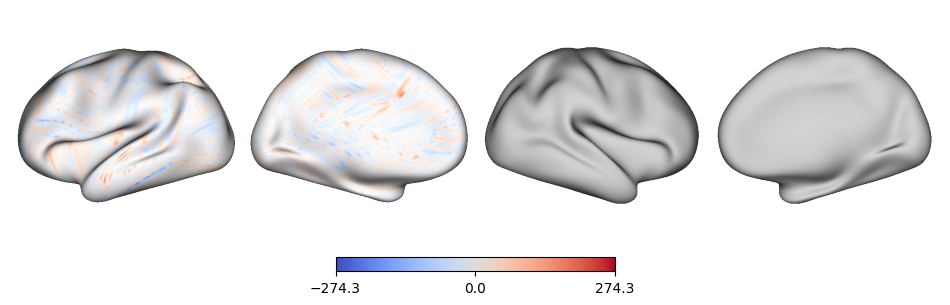

In [73]:
full_data = data[100]
c_data = full_data[:medial_wall_mask_64k.shape[0]]
# vertex_plot(c_data, template_cifti, cmap=plt.cm.viridis, pclip=(1, 99))

# sfm.surface_plot({"left": c_data[:32492]})

(<Axes: >, <surfplot.plotting.Plot at 0x3de72ffd0>)

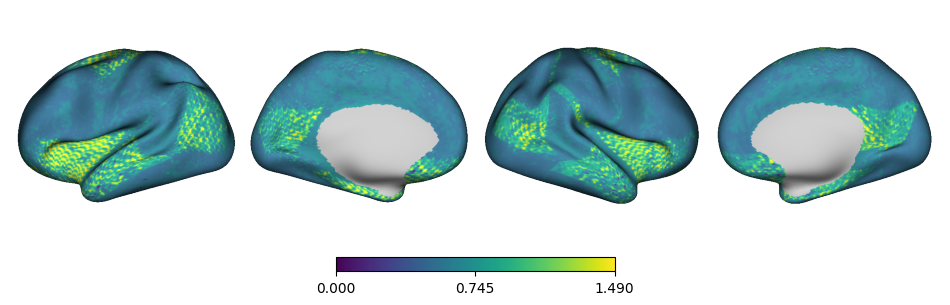

In [80]:
vertex_plot(mean_FC_s[0], template_cifti, cmap=plt.cm.viridis, pclip=(None, 99))

In [260]:
from scipy.sparse import csr_matrix

def smooth_cortex(data, surface_file, smoothing_iter=5):
    surf = nb.load(surface_file)
    vertices, faces = surf.darrays[0].data, surf.darrays[1].data
    n_vertices = len(vertices)

    # Create adjacency matrix
    adjacency = csr_matrix((n_vertices, n_vertices), dtype=np.float32)
    for face in faces:
        for i in range(3):
            adjacency[face[i], face[(i+1)%3]] = 1
            adjacency[face[(i+1)%3], face[i]] = 1

    # Normalize adjacency matrix
    adjacency = adjacency + csr_matrix(np.eye(n_vertices))  # Add self-loops
    degree = adjacency.sum(axis=1).A1
    normalized_adj = adjacency.multiply(1 / degree[:, None])

    # Smooth data
    smoothed_data = data.copy()
    for _ in range(smoothing_iter):
        smoothed_data = normalized_adj @ smoothed_data

    return smoothed_data

In [19]:
t_s, p_s = scipy.stats.ttest_ind(mean_FC_s[szp_index], mean_FC_s[~szp_index])
q_s = np.full(len(p_s), fill_value=np.nan)
q_s[~np.isnan(p_s)] = scipy.stats.false_discovery_control(p_s[~np.isnan(p_s)])

t_s_masked = t_s.copy()
# t_s_masked[p_s >= 0.2] = np.nan
t_s_masked[t_s > -1] = np.nan

(<Axes: >, <surfplot.plotting.Plot at 0x15522b8d0>)

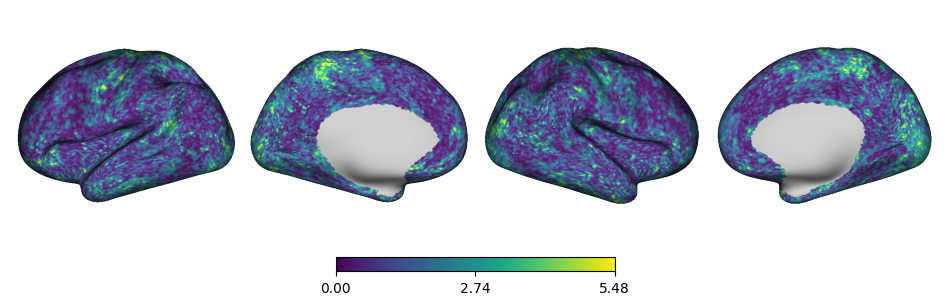

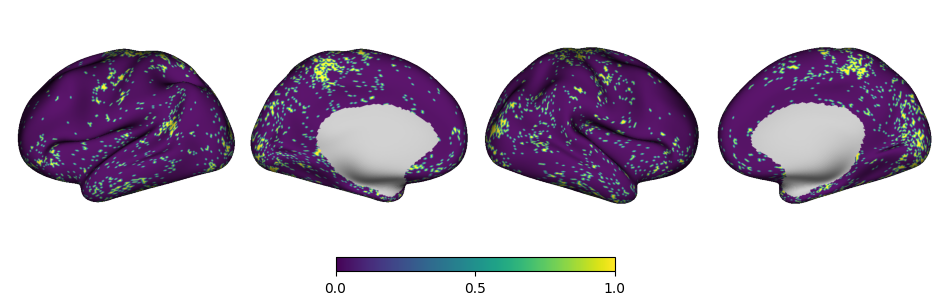

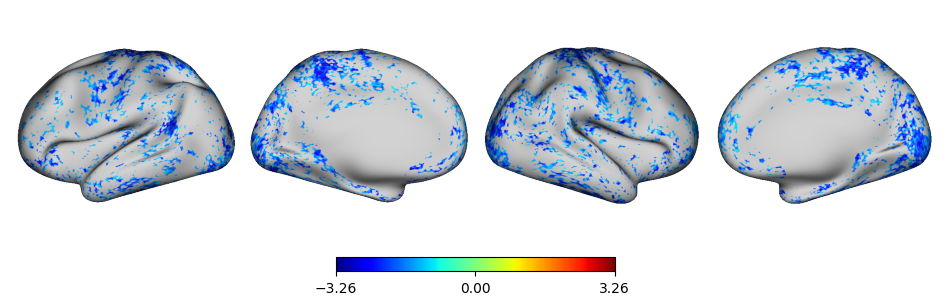

In [20]:
vertex_plot(-np.log(p_s), template_cifti, cmap=plt.cm.viridis, pclip=(None, 99))
vertex_plot((p_s < 0.05) * 1, template_cifti, cmap=plt.cm.viridis)
vertex_plot(t_s_masked, template_cifti, cmap=plt.cm.jet, pclip=(1, 99))

# Z-scores

In [243]:
HC_FC_s = mean_FC_s[~szp_index]

HC_FC_m, HC_FC_s = np.mean(HC_FC_s, axis=0), np.std(HC_FC_s, axis=0)

Context leak detected, msgtracer returned -1
2025-02-04 00:09:01.549 (3128.558s) [         26D373C]vtkOpenGLRenderWindow.c:876   WARN| vtkCocoaRenderWindow (0x64b2fd550): Failed to get red color buffer size (1280)
2025-02-04 00:09:01.549 (3128.559s) [         26D373C]vtkOpenGLRenderWindow.c:886   WARN| vtkCocoaRenderWindow (0x64b2fd550): Failed to get green color buffer size (1280)
2025-02-04 00:09:01.549 (3128.559s) [         26D373C]vtkOpenGLRenderWindow.c:896   WARN| vtkCocoaRenderWindow (0x64b2fd550): Failed to get blue color buffer size (1280)
2025-02-04 00:09:01.549 (3128.559s) [         26D373C]vtkOpenGLRenderWindow.c:906   WARN| vtkCocoaRenderWindow (0x64b2fd550): Failed to get alpha color buffer size (1280)


KeyboardInterrupt: 

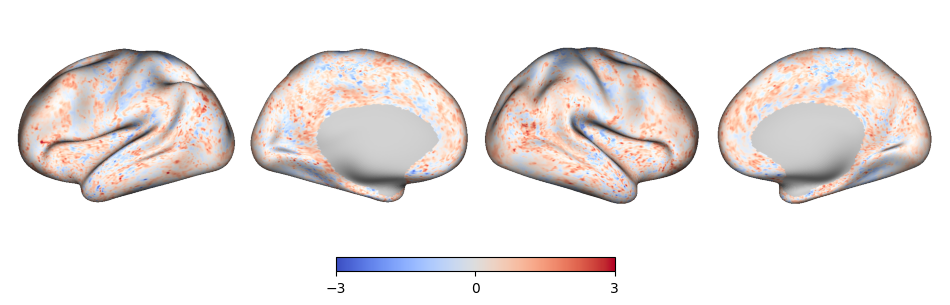

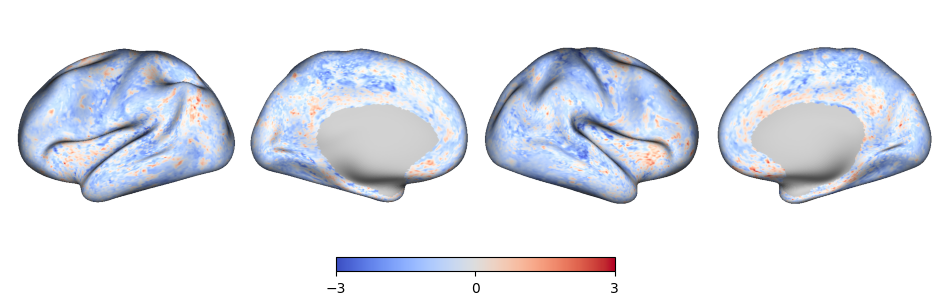

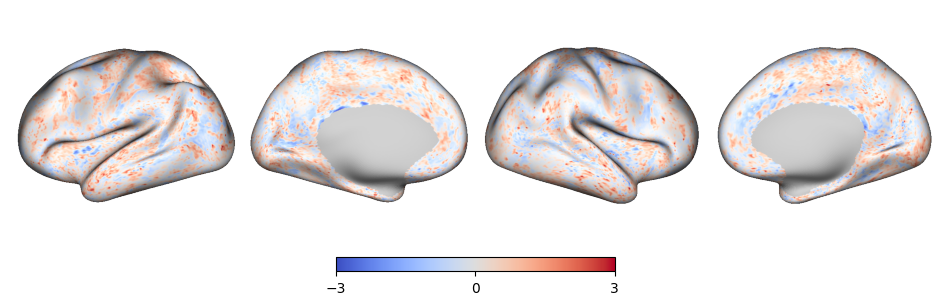

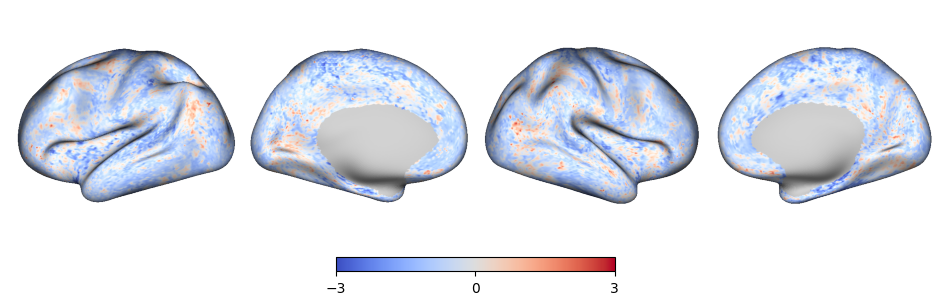

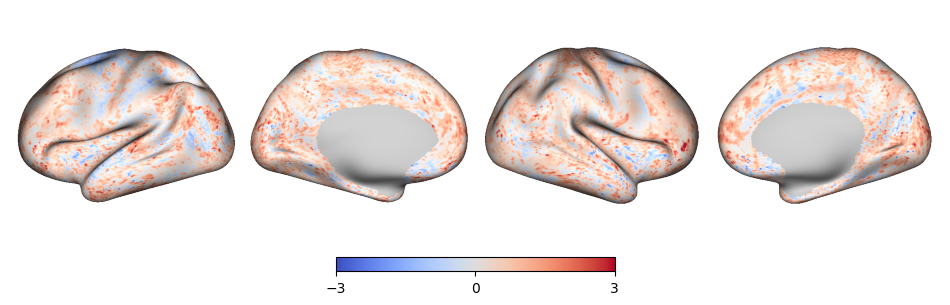

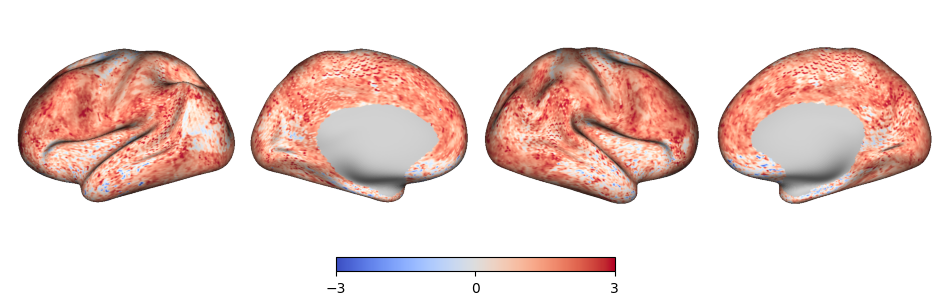

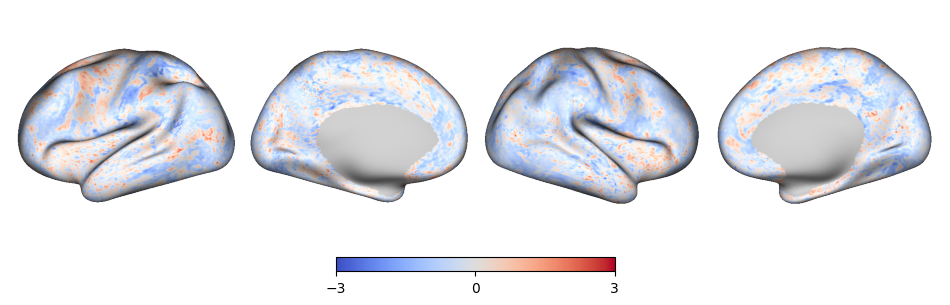

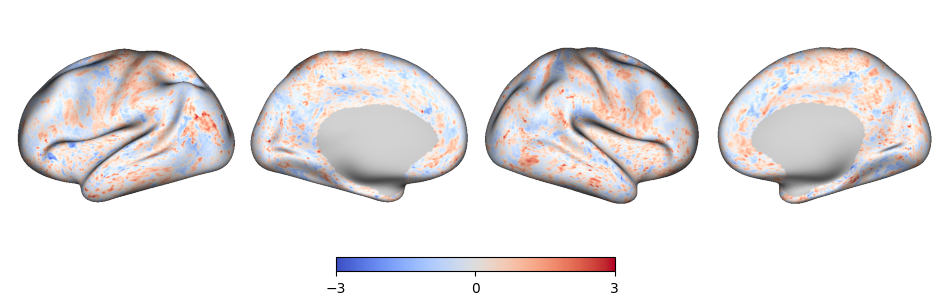

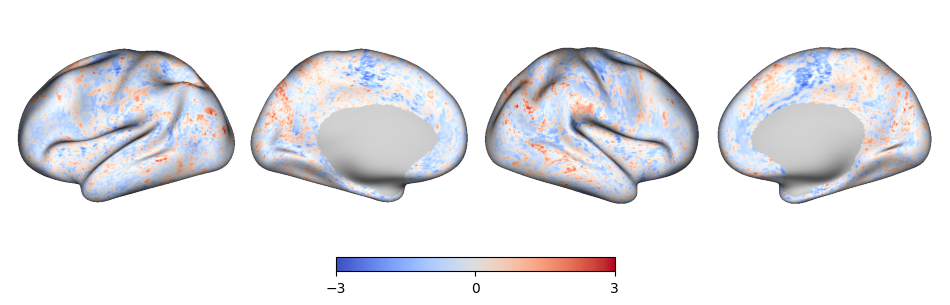

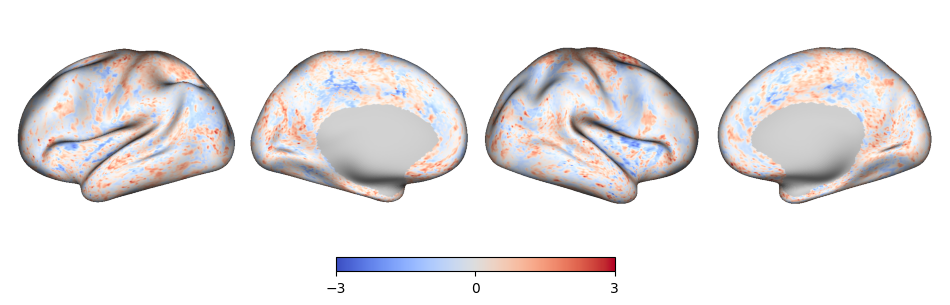

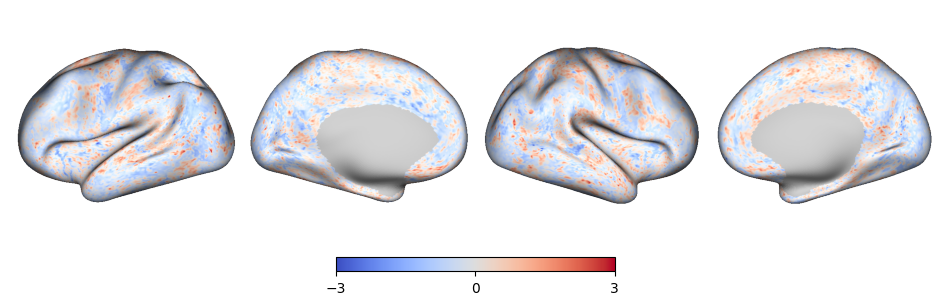

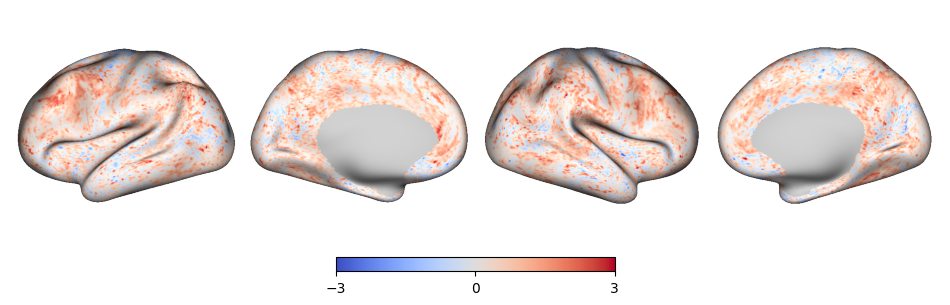

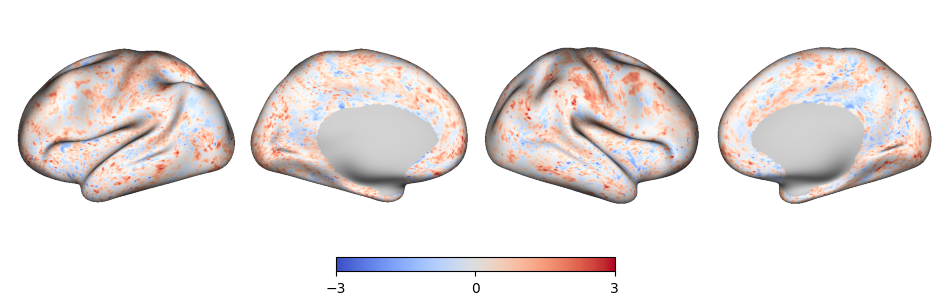

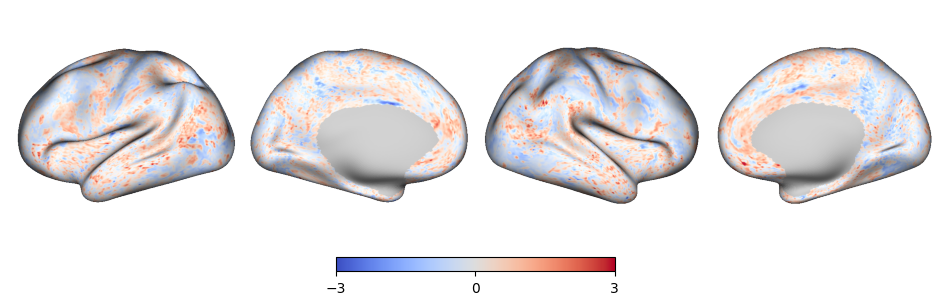

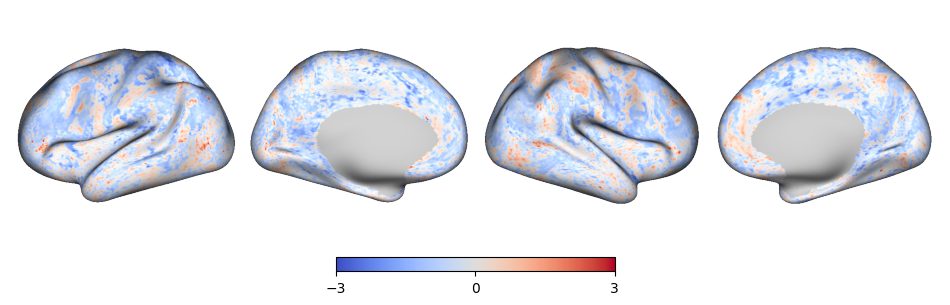

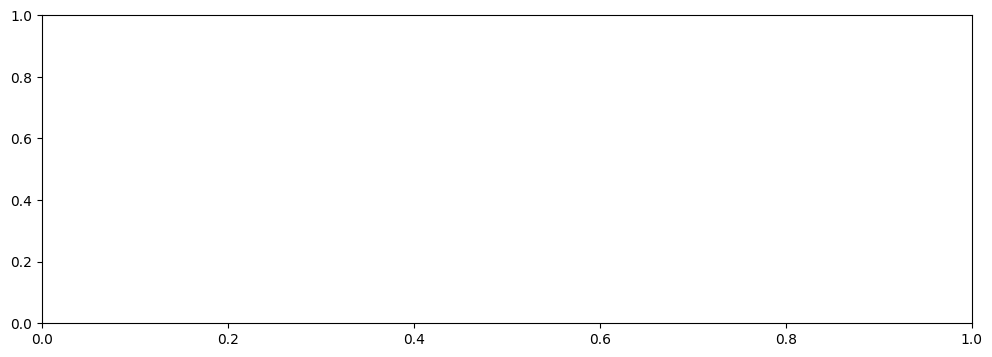

In [244]:
n_szp = np.sum(szp_index)
for i in np.arange(n_szp):
    # szp_FC_i = mean_FC_s[szp_index][i]
    szp_FC_i = mean_FC_s[~szp_index][i]
    szp_FC_z_score = (szp_FC_i - HC_FC_m) / (HC_FC_s + (HC_FC_s == 0))
    # szp_FC_z_score[np.abs(szp_FC_z_score) < 1.5] = np.nan
    
    vertex_plot(szp_FC_z_score, template_cifti, cmap=plt.cm.coolwarm, color_range=[-3, 3])